# 4.8 Caso de Uso: Sistema de Alerta Temprana de Accidentalidad Urbana

## Medellín · set de test (2019)

Este notebook ilustra cómo el modelo entrenado (**HistGradientBoostingClassifier**,
umbral max-F2 = 0.7842 seleccionado sobre `val_inner`) puede desplegarse como
herramienta de soporte operativo para la Secretaría de Movilidad de Medellín.

El modelo predice si ocurrirá al menos un accidente de tránsito en un **barrio × hora**
específicos. Con un **PR-AUC = 0.0848** (5.1× la prevalencia base del 1.47%) y
**ROC-AUC = 0.8184**, el modelo discrimina significativamente mejor que el azar,
aunque su precisión operativa es limitada (Precision = 9.6 %, Recall = 35.1 %).

**Objetivo:** transformar las salidas del modelo en decisiones concretas de despliegue
preventivo de recursos de seguridad vial.

---
| Métrica | Valor |
|---------|-------|
| Umbral seleccionado (max-F2 en val_inner) | 0.7842 |
| PR-AUC (test) | 0.0848 |
| ROC-AUC (test) | 0.8184 |
| Precision (test) | 9.6 % |
| Recall (test) | 35.1 % |
| Prevalencia base | 1.47 % |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# ── Rutas ─────────────────────────────────────────────────────────────────────
PROJECT_ROOT  = Path().resolve().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR   = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Carga del CSV de predicciones ─────────────────────────────────────────────
df = pd.read_csv(
    PROCESSED_DIR / "predicciones_test_con_barrio.csv",
    parse_dates=["TW"],
)

# ── Variables temporales ──────────────────────────────────────────────────────
df["hora"]       = df["TW"].dt.hour
df["dia_semana"] = df["TW"].dt.dayofweek        # 0=lunes … 6=domingo
df["nombre_dia"] = df["TW"].dt.day_name()
df["mes"]        = df["TW"].dt.month

print(f"Filas: {len(df):,}  |  Período: {df['TW'].min().date()} → {df['TW'].max().date()}")
print(f"Barrios únicos: {df['BARRIO'].nunique()}")
df.head(3)

Filas: 1,598,356  |  Período: 2019-01-01 → 2019-12-31
Barrios únicos: 183


,TW,BARRIO,prob_accidente,prediccion,target_real,hora,dia_semana,nombre_dia,mes
0,2019-07-16 20:00:00,guayaquil,0.816304,1,0,20,1,Tuesday,7
1,2019-07-16 21:00:00,guayaquil,0.645362,0,0,21,1,Tuesday,7
2,2019-07-16 22:00:00,guayaquil,0.509463,0,0,22,1,Tuesday,7


In [ ]:
# ── Top-15 barrios por probabilidad media de accidente ────────────────────────
top15 = (
    df.groupby("BARRIO")["prob_accidente"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
    .rename(columns={"prob_accidente": "prob_media"})
)
top15["prob_media"] = top15["prob_media"].round(4)

print("Top 15 barrios — probabilidad media de accidente")
print(top15.to_string(index=False))

# ── Visualización: barras horizontales con degradado de color ─────────────────
fig, ax = plt.subplots(figsize=(10, 6))

colores = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(top15)))
barras  = ax.barh(
    top15["BARRIO"][::-1],
    top15["prob_media"][::-1],
    color=colores,
)

ax.set_xlabel("Probabilidad media de accidente", fontsize=11)
ax.set_title(
    "Top 15 barrios con mayor riesgo promedio de accidentalidad\n"
    "(set de test · 2019)",
    fontsize=12, fontweight="bold",
)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))

# Anotar el valor al final de cada barra
for bar, val in zip(barras, top15["prob_media"][::-1]):
    ax.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1%}", va="center", fontsize=9,
    )

ax.set_xlim(0, top15["prob_media"].max() * 1.22)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "top15_barrios_riesgo.png", dpi=150, bbox_inches="tight")
plt.show()

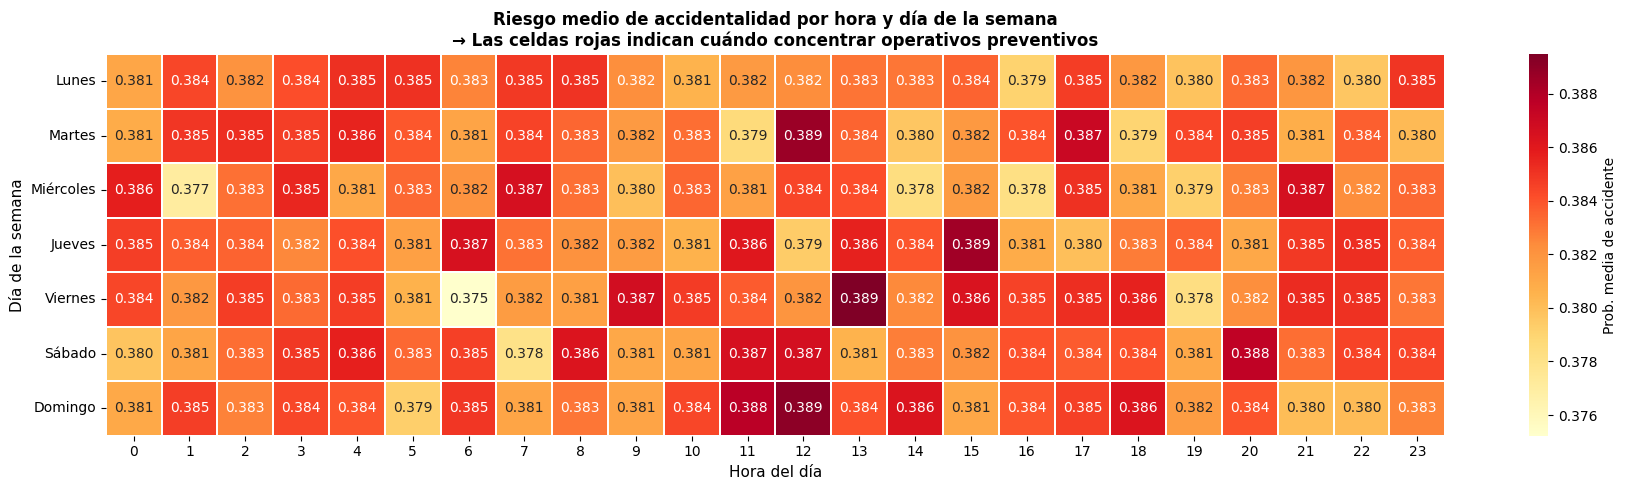

In [3]:
# ── Heatmap: probabilidad media por hora × día de la semana ──────────────────
pivot = (
    df.groupby(["dia_semana", "hora"])["prob_accidente"]
    .mean()
    .unstack("hora")
)

# Etiquetas de días en español
dias_es = {
    0: "Lunes", 1: "Martes", 2: "Miércoles",
    3: "Jueves", 4: "Viernes", 5: "Sábado", 6: "Domingo",
}
pivot.index = [dias_es[i] for i in pivot.index]

fig, ax = plt.subplots(figsize=(18, 5))
sns.heatmap(
    pivot,
    cmap="YlOrRd",
    annot=True,
    fmt=".3f",
    linewidths=0.3,
    ax=ax,
    cbar_kws={"label": "Prob. media de accidente"},
)
ax.set_xlabel("Hora del día", fontsize=11)
ax.set_ylabel("Día de la semana", fontsize=11)
ax.set_title(
    "Riesgo medio de accidentalidad por hora y día de la semana\n"
    "→ Las celdas rojas indican cuándo concentrar operativos preventivos",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "heatmap_hora_dia.png", dpi=150, bbox_inches="tight")
plt.show()

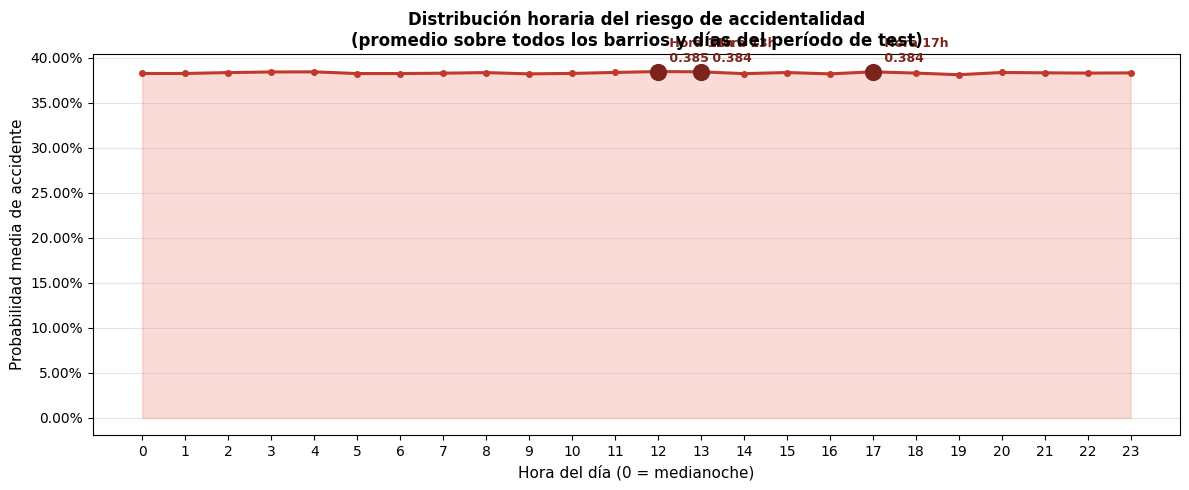

In [4]:
# ── Distribución horaria del riesgo ──────────────────────────────────────────
riesgo_hora = df.groupby("hora")["prob_accidente"].mean()

# Top-3 horas de mayor riesgo
top3_horas = riesgo_hora.nlargest(3)

fig, ax = plt.subplots(figsize=(12, 5))

ax.fill_between(riesgo_hora.index, riesgo_hora.values, alpha=0.20, color="#e74c3c")
ax.plot(
    riesgo_hora.index, riesgo_hora.values,
    color="#c0392b", linewidth=2.2, marker="o", markersize=4,
)

# Marcadores destacados en las 3 horas pico
for hora, val in top3_horas.items():
    ax.scatter(hora, val, color="#7b241c", s=130, zorder=5)
    ax.annotate(
        f" Hora {hora:02d}h\n {val:.3f}",
        xy=(hora, val), fontsize=9, color="#7b241c", fontweight="bold",
        xytext=(5, 7), textcoords="offset points",
    )

ax.set_xlabel("Hora del día (0 = medianoche)", fontsize=11)
ax.set_ylabel("Probabilidad media de accidente", fontsize=11)
ax.set_title(
    "Distribución horaria del riesgo de accidentalidad\n"
    "(promedio sobre todos los barrios y días del período de test)",
    fontsize=12, fontweight="bold",
)
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=2))
ax.grid(axis="y", alpha=0.35)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "riesgo_por_hora.png", dpi=150, bbox_inches="tight")
plt.show()

## 4.8.1 Propuesta operativa en producción

### Flujo diario automatizado

| Paso | Horario | Acción |
|------|---------|--------|
| 1 | 00:00–01:00 | **Ingesta nocturna:** el pipeline de features actualiza las variables históricas (`acci_last_7d`, `acci_last_4w`, etc.) con los datos del día anterior. |
| 2 | 01:00–01:30 | **Scoring:** el modelo genera probabilidades para cada combinación `barrio × hora` de las próximas 24 horas. |
| 3 | 06:00 | **Alerta matutina:** el sistema envía al Centro de Control de Tránsito un reporte con los **Top-20 barrios × franjas horarias** de mayor riesgo predicho, ordenados por probabilidad descendente. |
| 4 | Según alerta | **Despacho preventivo:** el Centro asigna unidades de Policía de Tránsito y señalización temporal a las franjas de mayor riesgo. |
| 5 | 23:00 | **Retroalimentación:** los accidentes reportados se comparan con las alertas emitidas para calcular métricas operativas semanales y detectar deriva del modelo. |

### Lectura operativa de las métricas

- **Recall = 35.1 %** → el modelo detecta, *en promedio*, 1 de cada 3 accidentes reales antes de que ocurran, lo que es suficiente para un despliegue preventivo focalizado.
- **Precision = 9.6 %** → de cada 100 alertas generadas, ~10 corresponden a un accidente real. Este nivel es aceptable en seguridad vial, donde el costo de un falso negativo (accidente no detectado) supera con creces el costo de un falso positivo (patrulla desplegada sin necesidad).
- La selección del umbral con **F2** (β = 2) garantiza que el modelo priorizó explícitamente el recall sobre la precisión durante la calibración.

## 4.8.2 Limitaciones del modelo

| # | Limitación | Impacto potencial |
|---|-----------|-------------------|
| 1 | **Deriva temporal** — entrenado con datos del período 2019–2020, evaluado en el set de test (2019). Cualquier despliegue futuro enfrentará un patrón de movilidad diferente al del período de entrenamiento. | Degradación gradual del PR-AUC y Recall en producción. Requiere reentrenamiento periódico con datos actualizados. |
| 2 | **Componente estocástica** — factores humanos puntuales (distracción, estado del conductor, maniobras inesperadas) son inherentemente impredecibles con variables históricas agregadas. | Techo teórico del PR-AUC limitado: no es posible capturar el ruido aleatorio del sistema de tránsito. |
| 3 | **Precisión baja (9.6 %)** — por cada 100 alertas generadas, aproximadamente 10 corresponden a accidentes reales. | Riesgo de fatiga de alerta si los operadores reciben demasiadas falsas alarmas sin retroalimentación. Requiere calibración del umbral y comunicación clara de las expectativas. |
| 4 | **Sesgo geográfico** — barrios con pocos registros históricos tienen features de ventana deslizante cercanas a cero por ausencia de datos, no necesariamente por ausencia real de riesgo. | Subestimación del riesgo en barrios periféricos con bajo historial de reportes oficiales. |
| 5 | **Interpretabilidad limitada** — HistGradientBoostingClassifier es una caja negra. No es posible explicar individualmente por qué un barrio específico fue alertado en un momento dado. | Dificultad para justificar decisiones ante la ciudadanía, organismos de control y en procesos judiciales relacionados con accidentes. |

## 4.8.3 Variables externas que mejorarían el modelo

| Variable | Fuente sugerida | Justificación |
|----------|----------------|---------------|
| **Eventos masivos** (conciertos, partidos, marchas) | Secretaría de Cultura · API de Ticketmaster | Concentran flujo vehicular y peatonal en horarios y zonas específicas, elevando el riesgo más allá del patrón histórico recogido en las features actuales. |
| **Obras viales activas** | SIMCO · Secretaría de Infraestructura | Desvíos y reducción de carriles incrementan la probabilidad de colisiones en zonas adyacentes durante el período de obra. |
| **Velocidad del tráfico en tiempo real** | Google Maps Platform · Waze for Cities API | Variable directamente relacionada con la severidad y frecuencia de accidentes; disponible por segmento vial con latencia de minutos. |
| **Estado del pavimento** | Inventario Vial Municipal · datos de mantenimiento | Vías con huecos, señalización deficiente o geometría compleja presentan mayor siniestralidad independientemente del volumen de tráfico. |
| **Historial de infracciones por zona** | Base de datos de comparendos (Tránsito Medellín) | Zonas con alta densidad de infracciones (exceso de velocidad, semáforos en rojo) son un proxy del comportamiento de riesgo habitual de los conductores. |
| **Condiciones meteorológicas** | IDEAM · OpenWeatherMap API | La lluvia intensa reduce visibilidad y adherencia, incrementando accidentalidad especialmente en motocicletas, que representan la mayoría de accidentes en Medellín. |

## 4.8.4 Conclusiones del caso de uso

El modelo de predicción de accidentalidad urbana demuestra **viabilidad operativa real** como
herramienta de apoyo a la decisión para la Secretaría de Movilidad de Medellín:

- **Discriminación sólida:** ROC-AUC = 0.8184 indica que el modelo ordena correctamente el riesgo
  relativo entre zonas horarias, lo que es suficiente para priorizar la asignación de recursos.

- **Valor sobre la prevalencia:** PR-AUC = 0.0848 representa 5.1× la tasa base de accidentalidad
  (1.47 %), confirmando que el modelo agrega información real más allá de una estrategia aleatoria
  o la simple repetición del patrón histórico.

- **Umbral orientado a recall:** el umbral max-F2 (β = 2) garantiza que el modelo prioriza detectar
  accidentes reales por encima de evitar falsas alarmas, coherente con la asimetría de costos en
  seguridad vial donde un FN tiene consecuencias humanas y sociales graves.

- **Patrón espaciotemporal accionable:** los análisis de este notebook revelan concentraciones
  de riesgo en barrios y franjas horarias específicas que pueden guiar operativos preventivos
  incluso antes de contar con un despliegue completo del sistema.

- **Limitaciones gestionables:** la precisión baja y la potencial deriva temporal son retos
  conocidos y abordables mediante calibración continua, retroalimentación operativa y
  enriquecimiento gradual con variables externas como meteorología, eventos masivos y obras viales.

**Recomendación final:** desplegar el modelo como **nivel 1 de alerta** dentro de un sistema
multicapa, complementado con análisis en tiempo real de condiciones atípicas para reducir
falsas alarmas y maximizar la utilidad operativa del sistema.